## Linear Regression

## Learning Objectives

1. Fit simple linear regression models and interpret coefficients in context
2. Fit multiple linear regression models and interpret coefficients in context
3. Fit multiple linear regression models with categorical predictors and interpret coefficients in context
4. Use RMSE and $R^2$ to compare multiple regression models
5. Identify and address any potential issues with multicollinearity
6. Use residual plots to identify violations of linearity or identify other useful predictors

## Response Variable Distribution

<Axes: xlabel='weekly_demand', ylabel='Count'>

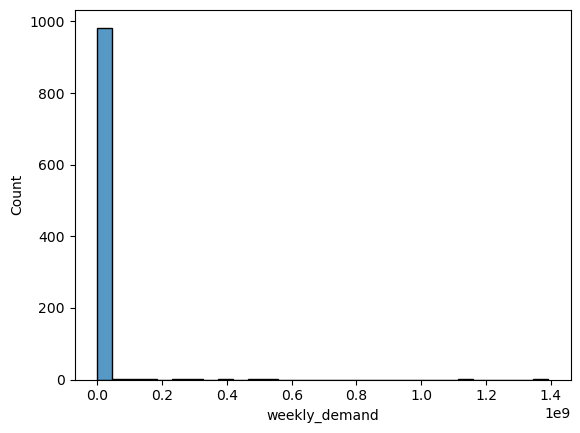

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/demand.csv")
sns.histplot(data=df, x="weekly_demand", bins=30)

## Transformation of Response

Often, the response variable will be transformed to make it look more like a normal distribution. For data that are right-skewed, this can be achieved using a log transformation. Other common transformations include:

- Square root transformation $\left(\sqrt{y}\right)$ for count data with increasing variance
- Power transformations $\left(y^\lambda\right)$ (e.g., $\lambda=2$ is a quadratic transformation)
- Logistic transformation $\left(\log\left(\frac{y}{1-y}\right)\right)$ for data between 0 and 1
- Arcsine transformation $\left(\arcsin \left(y\right)\right)$ also for data between 0 and 1

<Axes: xlabel='log_weekly_demand', ylabel='Count'>

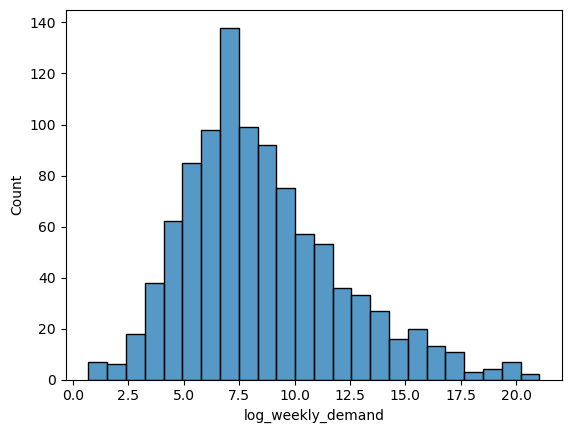

In [2]:
df["log_weekly_demand"] = np.log(df["weekly_demand"]+1)
sns.histplot(data=df, x="log_weekly_demand")

## Visual Inspection of Relationships

<Axes: xlabel='num_reviews', ylabel='log_weekly_demand'>

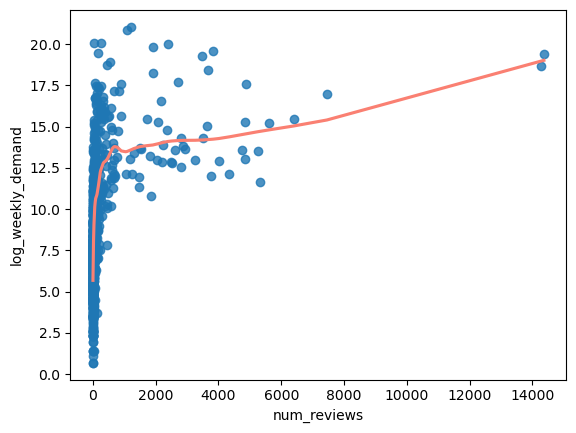

In [3]:
sns.regplot(data=df, x="num_reviews", y="log_weekly_demand", 
            lowess=True, line_kws={"color": "salmon"})

## Transformation of Predictor

For linear regression models, we would like relationships between predictors and the response to be linear. When this isn't the case, we might also transform the predictor variable to achieve a more linear relationships.

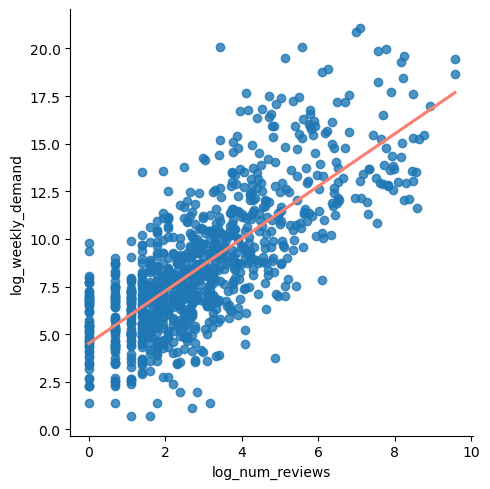

In [4]:
df["log_num_reviews"] = np.log(df["num_reviews"]+1)
sns.lmplot(data=df, x="log_num_reviews", y="log_weekly_demand", ci=False, line_kws={"color": "salmon"})

## Simple Linear Regression

The simple linear regression model assumes the following relationship between a response $y_i$ and a predictor $x_i$:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$$

- $y_i$: $i^{th}$ value of the response
- $x_i$: $i^{th}$ value of the predictor
- $\beta_0$: Intercept (expected value of response when predictor is 0)
- $\beta_1$: Slope (expected change in response when predictor increases by one unit)
- $\varepsilon_i$: Error, difference between true value and model predicted value $y_i - \beta_0 - \beta_1 x_i$

## Regression Models with Scikit-Learn

To fit a simple linear regression model using the Scikit-Learn library, we create a `LinearRegression` object.

```python
class sklearn.linear_model.LinearRegression(*, fit_intercept=True, copy_X=True, tol=1e-06, n_jobs=None, positive=False)
```

The `LinearRegression` object has a `fit` method:

```python
fit(X, y, sample_weight=None)
```

Here `X` is a dataframe/matrix containing information on just the predictors and `y` is a vector/series containing the response values. The resulting fitted object has attributes `intercept_` for the intercept and `coef_` for the slope parameter.

In [5]:
from sklearn.linear_model import LinearRegression

slr_model = LinearRegression()

X_slr = df[["log_num_reviews"]]
y = df["log_weekly_demand"]

slr_model.fit(X_slr, y)

print("Intercept: ", slr_model.intercept_)
print("Slope: ", slr_model.coef_)

Intercept:  4.515472430433779
Slope:  [1.37515451]


## Interpreting Regression Coefficients

We have obtained the following fitted model:

$$\hat{\text{LogDemand}}_i = 4.5 + 1.375 \times \text{LogReviews}_i$$

This means that when the log of number of reviews is zero, we would expect the log of weekly demand to be 4.5. For every one unit increase in the log of number of reviews, there is an increase of 1.375 in the log of weekly demand.

## Multiple Linear Regression

The multiple linear regression model extends simple linear regression to include more than one predictor:

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_P x_{iP} + \varepsilon_i$$

The interpretation of each $\beta_p$ is now the expected change in response for a one unit increase in $x_p$ ***while holding all other variables constant***.

## Visual Inspection of Multiple Relationships with Response

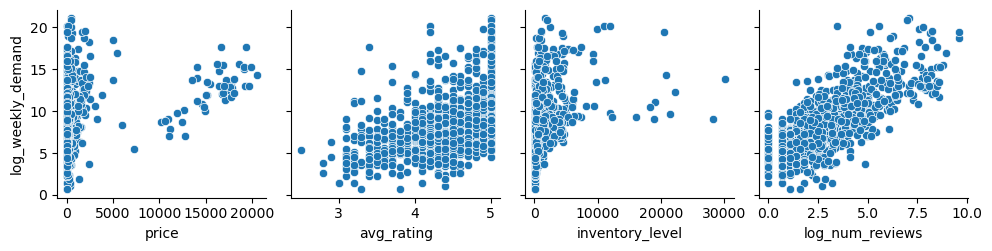

In [6]:
sns.pairplot(data=df, x_vars=["price", "avg_rating", "inventory_level", "log_num_reviews"], y_vars="log_weekly_demand")

## Transformation of Predictor Variables to Achieve Linearity

The linear model assumes that there is a linear relationship between each $x_p$ and $y$. We may transform $x_p$ to linearize these relationships and satisfy the assumptiosn of the model.

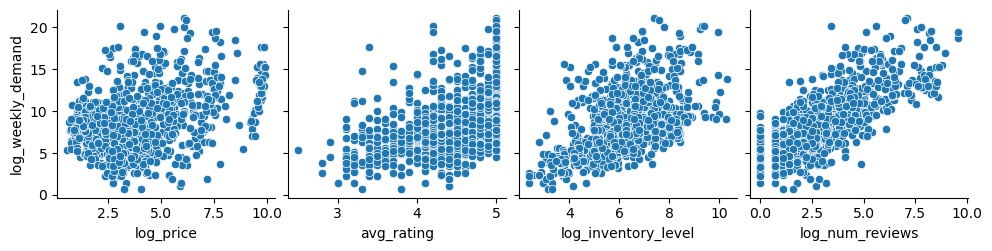

In [7]:
df["log_price"] = np.log(df["price"]+1)
df["log_inventory_level"] = np.log(df["inventory_level"]+1)
sns.pairplot(data=df, x_vars=["log_price", "avg_rating", "log_inventory_level", "log_num_reviews"], y_vars="log_weekly_demand")

## Fitting Multiple Linear Regression Models with Scikit-Learn

In [8]:
mlr_model = LinearRegression()

X_mlr = df[["log_num_reviews", "log_price", "avg_rating", "log_inventory_level"]]

mlr_model.fit(X_mlr, y)

print("Intercept: ", mlr_model.intercept_)
print("Slope: ", mlr_model.coef_)

Intercept:  -0.7074831150535825
Slope:  [ 1.39602918 -0.20883581  0.23413352  0.78581013]


## Interpretation of Regression Coefficients in Multiple Linear Regression

We have the following fitted model:

$$\hat{\text{LogDemand}}_i = -0.707 + 1.396 \times \text{LogReviews}_i - 0.209 \times \text{LogPrice}_i + 0.234 \times \text{AvgRating}_i + 0.786 \times \text{LogInventory}_i$$

As an example, assume we want to interpret the meaning of the coefficient for log price. We would say that a one unit increase in log price results in a decrease of 0.186 in log demand, while holding log reviews, average rating, and log inventory constant.

## Regression with Categorical Variables

Categorical variables may also provide important information about the response variable.

<Axes: xlabel='log_inventory_level', ylabel='log_weekly_demand'>

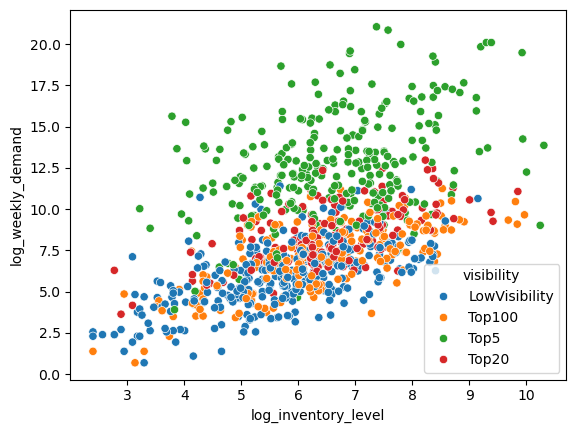

In [9]:
sns.scatterplot(data=df, x="log_inventory_level", y="log_weekly_demand", hue="visibility")

## Categorical Variables Create Different Regression Lines

When a categorical variable is included in a regression model, it essentially results in the creation of multiple regression lines with the same slopes, but different intercepts.

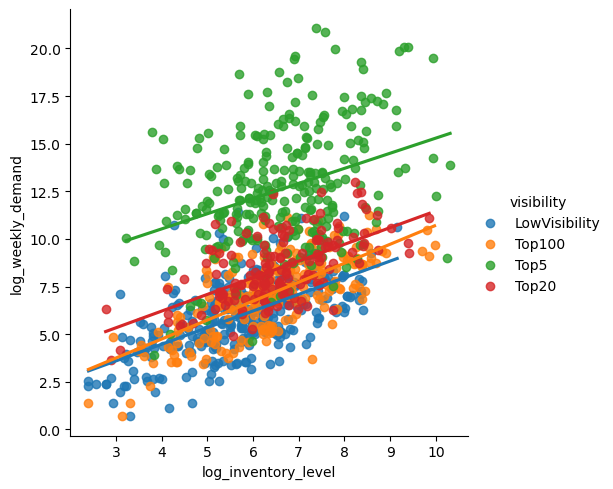

In [10]:
sns.lmplot(data=df, x="log_inventory_level", y="log_weekly_demand", hue="visibility", ci=False)

## Creating Predictors for Categorical Variables Using Dummy Variables

To incorporate a categorical variable with $K$ categories into a regression model, $K-1$ separate predictors are created: $x_1, x_2, \dots, x_{K-1}$. One category serves as the reference category, and the predictors for the other categories are dummy variables, where $x_k=1$ if an observation belongs to category $k$ and 0 otherwise.

For example, if a categorical variable had categories Red, Blue, and Green. Then we might choose Blue as the reference category, and the dummy variables would be as follows:

- Blue implies $x_1 = 0, x_2 = 0$
- Green implies $x_1 = 1, x_2 = 0$
- Red implies $x_1 = 0, x_2 = 1$


## Creating Dummy Variables Using Pandas

We create dummy variables using `pd.get_dummies`:

```python
pandas.get_dummies(data, prefix=None, prefix_sep='_', dummy_na=False, columns=None, sparse=False, drop_first=False, dtype=None)
```

This takes a dataframe and variables specified in `columns` and creates dummy variables for each variable. We set `drop_first` to `True` to let one category serve as a reference and set `dtype` to `int` to make them numeric variables.

In [11]:
df = pd.get_dummies(data=df, columns=["visibility"], drop_first=True, dtype="int")
df.head()

,quarter,day,holiday,category,parent,brand,supplier,fulfillment,prime,labor_regime,...,search_rank,packaging_quality,weekly_demand,log_weekly_demand,log_num_reviews,log_price,log_inventory_level,visibility_Top100,visibility_Top20,visibility_Top5
0,Q4-Holiday,Tue,0,Books,Samsung,Galaxy,Publisher,FBA,1,High,...,1.4,96.6,2983,8.001020,2.397895,4.058384,7.939159,0,0,0
1,Q2,Sat,0,Clothing,Nike,NikeRunning,Publisher,MerchantFulfilled,0,High,...,1.0,72.5,133,4.897840,0.693147,3.982696,4.276666,1,0,0
2,Q3,Thu,0,Clothing,Sony,NikeRunning,Importer,MerchantFulfilled,0,High,...,1.0,72.9,198,5.293305,2.772589,4.219717,6.796824,0,0,0
3,Q4-Holiday,Sat,0,Electronics,Samsung,Galaxy,AuthorizedDistributor,FBA,1,High,...,83.1,100.0,1431931,14.174535,4.691348,7.688709,7.999679,0,0,1
4,Q1,Fri,0,Clothing,Nike,NikeRunning,AuthorizedDistributor,FBA,1,Low,...,23.7,94.3,2062,7.631917,2.079442,4.413696,6.230481,0,1,0


## Regression with Dummy Variables

Including dummy variables for a categorical variable with $K$ categories essentially creates a regression line where each category has its own intercept. For example, let $x_1$ be a quantitative predictor and let $x_2$ and $x_3$ represent dummy variables for a categorical variable with $K=3$ categories. The full regression equation would be:

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \beta_3 x_{i3} + \varepsilon_i$$

The three regression lines are as follows:

- $\beta_0 + \beta_1 x_{i1}$ when $x_{i2} = x_{i3} = 0$
- $\left(\beta_0 + \beta_2\right) + \beta_1 x_{i1}$ when $x_{i2} = 1, x_{i3} = 0$
- $\left(\beta_0 + \beta_3\right) + \beta_1 x_{i1}$ when $x_{i2} = 0, x_{i3} = 1$

## Fitting Regression Models with Categorical Variables

In [12]:
cat_model = LinearRegression()

X_cat = df[["log_num_reviews", "log_price", "avg_rating", "log_inventory_level", 
            "visibility_Top100", "visibility_Top20", "visibility_Top5"]]

cat_model = cat_model.fit(X_cat, y)

print("Intercept: ", cat_model.intercept_)
print("Slope: ", cat_model.coef_)

Intercept:  -0.22417519980789358
Slope:  [ 0.88251988 -0.26407196  0.40814933  0.67527441  0.06494373  0.82415878
  3.51568109]


## Interpreting Regression Models with Categorical Variables

The resulting estimated regression equation is as follows:

$$\begin{align}
\hat{\text{LogDemand}}_i &= -0.224 + 0.883 \times \text{LogReviews}_i - 0.264 \times \text{LogPrice}_i  + 0.408 \times \text{AvgRating}_i +\\
& 0.675 \times \hat{\text{LogInventory}_i} + 0.065 \times \text{VisTop100}_i + 0.824 \times \text{VisTop20} + 3.516 \times \text{VisTop5}
\end{align}$$

The reference category is for the low visibility group and we can see that all other groups have a higher intercept (positive coefficients). For a specific category, we could find the exact regression equation. For example, for the top visibility group (VisTop5) we would have:

$$\hat{\text{LogDemand}}_i = (-0.224 + 3.516) + 0.883 \times \text{LogReviews}_i - 0.264 \times \text{LogPrice}_i  + 0.408 \times \text{AvgRating}_i + 0.675 \times \text{LogInventory}_i$$

## Evaluating Regression Models

We need a way to compare models and see which one is "better". There are two common metrics for this. One is using **root mean squared error**:

$$\sqrt{\frac{1}{n} \sum_{i=1}^n \left(y_i - \hat{y}_i\right)^2}$$

Another commonly used metric is the coefficient of determination $R^2$:

$$1-\frac{\sum_{i=1}^n \left(y_i - \hat{y}_i\right)^2}{\sum_{i=1}^n \left(y_i - \bar{y}\right)^2}$$

The root mean squared error (**RMSE**) is measure of how close the predictions are to true values in your dataset whereas $R^2$ is a the proportion of variability in the response explained by the model. Smaller values for RMSE indicate better predictive power on your dataset. Values close to 1 for $R^2$ indicate your model explains almost everything about the response.

## Metrics in Scikit-Learn

The Scikit-Learn library contains a variety of metrics for evaluating models including `root_mean_squared_error` and `r2_score`.

```python
sklearn.metrics.root_mean_squared_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')
```

```python
sklearn.metrics.r2_score(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', force_finite=True)
```

In their very basic form, both just require the true values for the response and the predicted values from the model.

## Evaluating Models with RMSE and $R^2$

In [13]:
from sklearn.metrics import root_mean_squared_error, r2_score

slr_preds = slr_model.predict(X_slr)
mlr_preds = mlr_model.predict(X_mlr)
cat_preds = cat_model.predict(X_cat)

print("SLR RMSE: ", root_mean_squared_error(slr_preds, y))
print("MLR RMSE: ", root_mean_squared_error(mlr_preds, y))
print("Cat RMSE: ", root_mean_squared_error(cat_preds, y))

SLR RMSE:  2.350073543937466
MLR RMSE:  1.9918103752896283
Cat RMSE:  1.6743870828881255


In [14]:
print("SLR R2: ", r2_score(slr_preds, y))
print("MLR R2: ", r2_score(mlr_preds, y))
print("Cat R2: ", r2_score(cat_preds, y))

SLR R2:  0.2196886488165739
MLR R2:  0.5404635223597427
Cat R2:  0.7138341876776378


## RMSE, $R^2$, and Parsimonious Models

One feature of RMSE and $R^2$ is that they will always improve as you add more predictors when you calculate them using the data on which your model was fit/trained. This is true even if the additional predictors are not related to the response at all.

In practice, you want to achieve a balance between a model that can predict when, but is also simple. As you add predictors, you may consider if the increase in $R^2$ or decrease in $RMSE$ warrants the inclusion of an additional variable.

## Multicollinearity

One common thing to watch out for in regression modeling is multicollinearity. This occurs when two predictors are highly correlated to the point where they are essentially providing the same information about the response. An extreme example of this would be including the same predictor twice (perfect correlation). In this case we would essentially be fitting the following model:

$$\begin{align}
y_i &= \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i1} + \varepsilon_i \\
y_i &= \beta_0 + \left(\beta_1 + \beta_2\right) x_{i1} + \varepsilon_i
\end{align}$$

We can see that we could choose an infinite number of values for $\beta_1$ and $\beta_2$ and still get the same regression line. Even without perfect correlation, strong multicollinearity can lead to instability in estimates which can ultimately hurt predictive performance.

## Multicollinearity Example

In [15]:
df["log_warehouse_capacity"] = np.log(df["warehouse_capacity"])

<Axes: xlabel='log_warehouse_capacity', ylabel='log_inventory_level'>

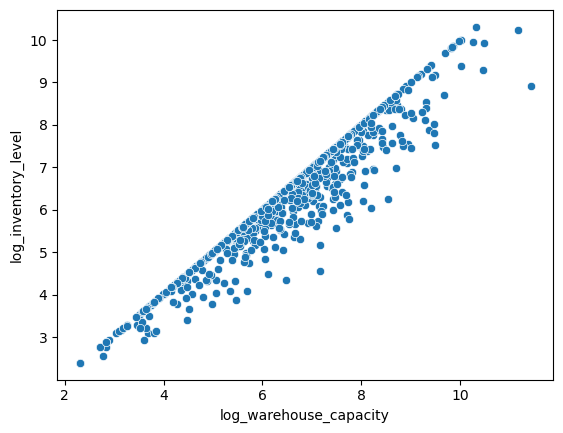

In [16]:
sns.scatterplot(data=df, x="log_warehouse_capacity", y="log_inventory_level")

## Effect of Multicollinearity on Regression

In [17]:
inv_model = LinearRegression()
ware_model = LinearRegression()
inv_ware_model = LinearRegression()

X_inv = df[["log_inventory_level"]]
X_ware = df[["log_warehouse_capacity"]]
X_inv_ware = df[["log_inventory_level", "log_warehouse_capacity"]]

inv_model.fit(X_inv, y)
ware_model.fit(X_ware, y)
inv_ware_model.fit(X_inv_ware, y)

print("Coef: ", inv_model.coef_)
print("Coef: ", ware_model.coef_)
print("Coef: ", inv_ware_model.coef_)

Coef:  [1.26869854]
Coef:  [1.36425214]
Coef:  [-1.08338254  2.36669898]


## Checking Linearity Assumption

To check the assumption of linearity for a model, we can compute the **residuals**:

$$r_i = y_i - \hat{y}_i$$

We can then plot specific predictors or the predicted values against these residuals to look for any violations of linearity. In this plot, we don't want to see any nonlinear patterns. Nonlinear patterns would suggest a violation of linearity.

Text(0, 0.5, 'Residuals')

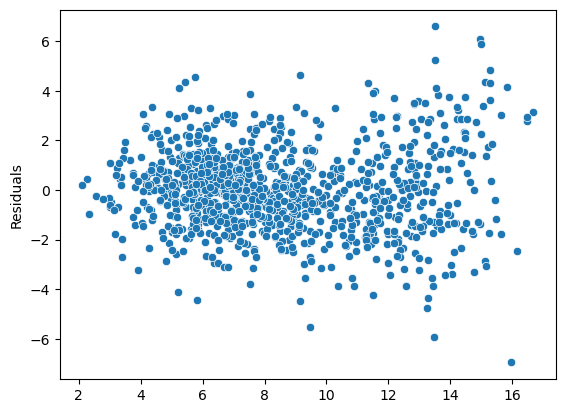

In [18]:
resids = y - cat_preds

sns.scatterplot(x = cat_preds, y = resids).set_ylabel("Residuals")

## Example of Violation of Linearity

Text(0, 0.5, 'Residuals')

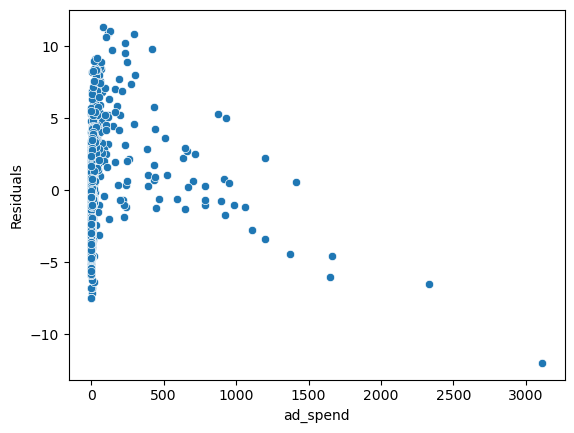

In [19]:
X_ad = df[["ad_spend"]]

ad_model = LinearRegression()
ad_model.fit(X_ad, y)
ad_preds = ad_model.predict(X_ad)
ad_resids = y - ad_preds

sns.scatterplot(data=df, x="ad_spend", y=ad_resids).set_ylabel("Residuals")

## Fixing Violation of Linearity via Transformation of Predictor

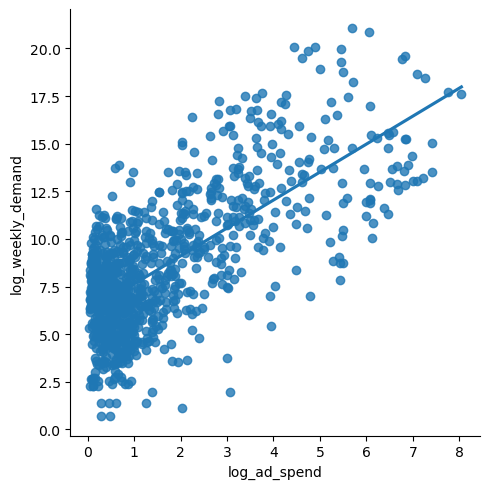

In [20]:
df["log_ad_spend"] = np.log(df["ad_spend"]+1)
sns.lmplot(data=df, x="log_ad_spend", y="log_weekly_demand", ci=False)

## Using Residual Plots to Inspect Violations of Linearity

Text(0, 0.5, 'Residuals')

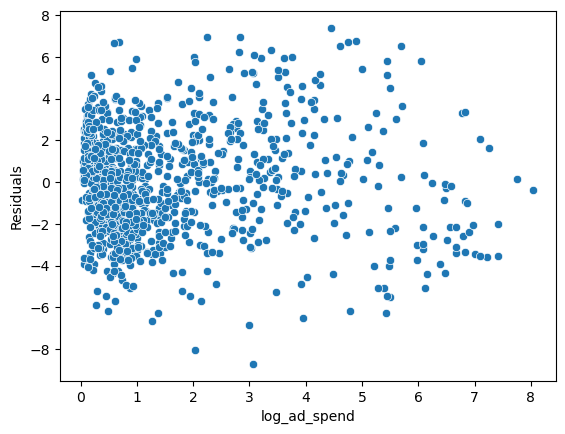

In [21]:
X_log_ad = df[["log_ad_spend"]]

log_ad_model = LinearRegression()
log_ad_model.fit(X_log_ad, y)
log_ad_preds = log_ad_model.predict(X_log_ad)
log_ad_resids = y - log_ad_preds

sns.scatterplot(data=df, x="log_ad_spend", y=log_ad_resids).set_ylabel("Residuals")

## Comparing Residuals to Other Potentially Useful Predictors

It's also possible to use the residuals of a model to explore potentially useful predictors to include in the model. If we plot out-of-model predictors against the current model's residuals and see a trend or pattern, this may suggest there are patterns that aren't explained by our current model that could be explained by these other predictors

Text(0, 0.5, 'Residuals')

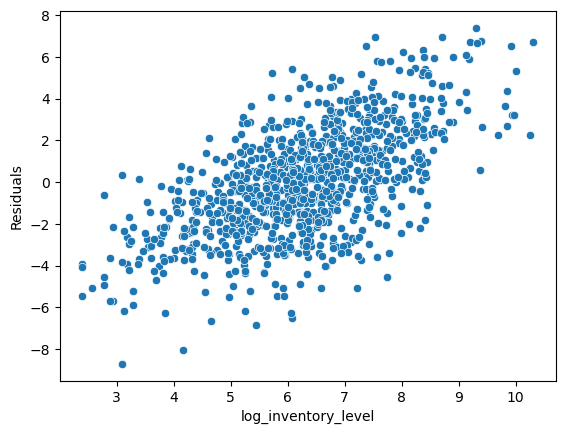

In [22]:
sns.scatterplot(data=df, x="log_inventory_level", y=log_ad_resids).set_ylabel("Residuals")

## Adding Potentially Useful Predictor and Checking Residuals

Text(0, 0.5, 'Residuals')

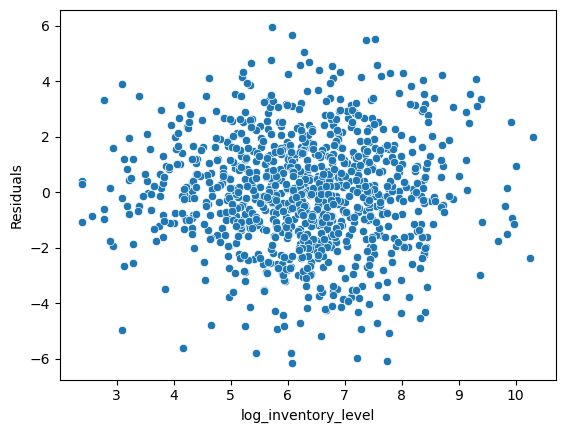

In [23]:
X_ad_inv = df[["log_ad_spend", "log_inventory_level"]]

ad_inv_model = LinearRegression()
ad_inv_model.fit(X_ad_inv, y)
ad_inv_preds = ad_inv_model.predict(X_ad_inv)
ad_inv_resids = y - ad_inv_preds

sns.scatterplot(data=df, x="log_inventory_level", y=ad_inv_resids).set_ylabel("Residuals")